# EDA Analytics For bussiness

In [ ]:
# Business EDA
import pandas as pd

def worksheet():
    df = pd.read_csv('data/transformed_clean_sales_data.csv')
    return df

df = worksheet()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 882 entries, 0 to 881
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OrderDate       882 non-null    object 
 1   SalesID         882 non-null    object 
 2   SalesName       882 non-null    object 
 3   InvoiceNo       882 non-null    object 
 4   CustomerName    882 non-null    object 
 5   OrderValue      882 non-null    float64
 6   DiscountValue   882 non-null    float64
 7   SalesValue      882 non-null    float64
 8   SalesReturn     882 non-null    float64
 9   CreditedAmount  882 non-null    float64
 10  Commission      882 non-null    float64
 11  Year            882 non-null    int64  
 12  Month           882 non-null    object 
 13  Day             882 non-null    object 
 14  CustomerID      882 non-null    object 
 15  NetSales        882 non-null    float64
 16  DueAmount       882 non-null    float64
dtypes: float64(8), int64(1), object(8)


#### 1. SALES ANALYTICS (Business KPIs)
*  Overall KPIs

In [4]:
kpis = {
    "Total Sales": df['SalesValue'].sum(),
    "Net Sales": df['NetSales'].sum(),
    "Total Collection": df['CreditedAmount'].sum(),
    "Total Due": df['DueAmount'].sum(),
    "Total Customers": df['CustomerID'].nunique(),
    "Total Executives": df['SalesID'].nunique(),
}

kpis

{'Total Sales': 11662682.360000001,
 'Net Sales': 11243294.26,
 'Total Collection': 7742840.0,
 'Total Due': 3500454.2600000002,
 'Total Customers': 180,
 'Total Executives': 8}

###  Monthly Sales Trend

In [5]:
monthly_sales = (
    df.groupby(['Year', 'Month'])
    .agg(Sales=('SalesValue','sum'))
    .reset_index()
)

In [6]:
monthly_sales

,Year,Month,Sales
0,2025,April,961185.62
1,2025,August,1341092.67
2,2025,December,1182321.56
3,2025,February,687594.20
4,2025,January,1216206.39
5,2025,July,1086992.29
6,2025,June,482892.48
7,2025,March,1057031.62
8,2025,May,171635.04
9,2025,November,1760313.52


In [ ]:
# Top Selling Months
monthly_sales.sort_values('Sales', ascending=False).head(10)

,Year,Month,Sales
9,2025,November,1760313.52
1,2025,August,1341092.67
4,2025,January,1216206.39
2,2025,December,1182321.56
11,2025,September,1113531.79
5,2025,July,1086992.29
7,2025,March,1057031.62
0,2025,April,961185.62
3,2025,February,687594.20
10,2025,October,601885.18


##  2. CUSTOMER BEHAVIOR ANALYSIS

In [10]:
customer_analysis = (
    df.groupby(['CustomerID','CustomerName'])
    .agg({
        'SalesValue':'sum',
        'NetSales':'sum',
        'DueAmount':'sum',
        'InvoiceNo':'count'
    })
    .rename(columns={'InvoiceNo':'Frequency'})
    .reset_index()
)

customer_analysis.sort_values('SalesValue', ascending=False).head(10)

,CustomerID,CustomerName,SalesValue,NetSales,DueAmount,Frequency
172,CUST00173,Swift Mart,2438220.80,2438220.80,721460.80,34
78,CUST00079,Kawchar Store,1889454.68,1889454.68,633723.68,53
75,CUST00076,Jui Crockeries,1420290.30,1369944.80,287928.80,36
49,CUST00050,Emon Enterprise,765112.45,497702.45,497302.45,12
98,CUST00099,Maria Enterprise,226808.00,226808.00,50358.00,28
47,CUST00048,Dali Super Shop,202456.41,202456.41,36624.41,22
140,CUST00141,Royel Kitchen,201062.84,201062.84,-5947.16,21
154,CUST00155,Sayed Gift Corner,181319.50,181319.50,126682.50,10
96,CUST00097,Mahir Exclusive,169719.50,169719.50,55719.50,23
171,CUST00172,Suruchi Enterprise,169444.00,169444.00,33994.00,9


* 💰 High Value Customers

In [11]:
customer_analysis.sort_values('SalesValue', ascending=False).head(20)

,CustomerID,CustomerName,SalesValue,NetSales,DueAmount,Frequency
172,CUST00173,Swift Mart,2438220.80,2438220.80,721460.80,34
78,CUST00079,Kawchar Store,1889454.68,1889454.68,633723.68,53
75,CUST00076,Jui Crockeries,1420290.30,1369944.80,287928.80,36
49,CUST00050,Emon Enterprise,765112.45,497702.45,497302.45,12
98,CUST00099,Maria Enterprise,226808.00,226808.00,50358.00,28
47,CUST00048,Dali Super Shop,202456.41,202456.41,36624.41,22
140,CUST00141,Royel Kitchen,201062.84,201062.84,-5947.16,21
154,CUST00155,Sayed Gift Corner,181319.50,181319.50,126682.50,10
96,CUST00097,Mahir Exclusive,169719.50,169719.50,55719.50,23
171,CUST00172,Suruchi Enterprise,169444.00,169444.00,33994.00,9


In [24]:
#  High Due Customers
customer_analysis.sort_values('DueAmount', ascending=False).head(20)

,CustomerID,CustomerName,SalesValue,NetSales,DueAmount,Frequency
172,CUST00173,Swift Mart,2438220.80,2438220.80,721460.80,34
78,CUST00079,Kawchar Store,1889454.68,1889454.68,633723.68,53
49,CUST00050,Emon Enterprise,765112.45,497702.45,497302.45,12
75,CUST00076,Jui Crockeries,1420290.30,1369944.80,287928.80,36
154,CUST00155,Sayed Gift Corner,181319.50,181319.50,126682.50,10
97,CUST00098,Mahira Exclusive,131570.50,131570.50,116570.50,5
79,CUST00080,Kawser Store,93086.40,93086.40,93086.40,1
144,CUST00145,S.S Garden,108768.00,108768.00,66456.00,7
163,CUST00164,Silva Crockeries,99781.50,99781.50,59781.50,4
96,CUST00097,Mahir Exclusive,169719.50,169719.50,55719.50,23


In [23]:
# Customer Frequency Behavior
customer_analysis.sort_values('Frequency', ascending=False).head(20)

,CustomerID,CustomerName,SalesValue,NetSales,DueAmount,Frequency
78,CUST00079,Kawchar Store,1889454.68,1889454.68,633723.68,53
75,CUST00076,Jui Crockeries,1420290.30,1369944.80,287928.80,36
172,CUST00173,Swift Mart,2438220.80,2438220.80,721460.80,34
98,CUST00099,Maria Enterprise,226808.00,226808.00,50358.00,28
72,CUST00073,Jhenaida Enterprise,127605.90,122683.90,22723.90,28
96,CUST00097,Mahir Exclusive,169719.50,169719.50,55719.50,23
47,CUST00048,Dali Super Shop,202456.41,202456.41,36624.41,22
140,CUST00141,Royel Kitchen,201062.84,201062.84,-5947.16,21
141,CUST00142,Ruma Enterprise,50089.50,50089.50,50089.50,17
74,CUST00075,Jononi Enterprise,74418.10,74418.10,26518.10,14


#### 3. SALES EXECUTIVE ANALYSIS
*  Executive Performance

In [15]:
exec_analysis = (
    df.groupby(['SalesID','SalesName'])
    .agg({
        'SalesValue':'sum',
        'NetSales':'sum',
        'CreditedAmount':'sum',
        'DueAmount':'sum',
        'CustomerID':'nunique'
    })
    .rename(columns={'CustomerID':'Customers'})
    .reset_index()
)

In [16]:
 exec_analysis.sort_values('SalesValue', ascending=False).head(10)

,SalesID,SalesName,SalesValue,NetSales,CreditedAmount,DueAmount,Customers
0,EMWS001,Al Amin,3413421.72,3410021.72,2864844.0,545177.72,50
2,EMWS003,Sajib Kumar Biswas,2061305.14,1991978.99,1626819.0,365159.99,35
7,EMWS008,Yousuf Mazumder Anik,1913354.81,1866998.56,1425175.0,441823.56,33
4,EMWS005,Mynuddin Hasan Hridoy,1226144.34,1224155.34,576110.0,648045.34,13
5,EMWS006,ATM Nur Hossen Rumel,1090488.65,813499.15,400.0,813099.15,32
6,EMWS007,Mohammad Sumon,1025843.70,1009438.50,514242.0,495196.50,20
3,EMWS004,Sujoy Kumar Biswas,917692.00,912770.00,495250.0,417520.00,17
1,EMWS002,Sanjoy Hore,14432.00,14432.00,240000.0,-225568.00,2


In [18]:
# 💸 Collection Efficiency
exec_analysis['CollectionRate'] = (
    exec_analysis['CreditedAmount'] / exec_analysis['SalesValue']
) * 100

exec_analysis.sort_values('CollectionRate', ascending=False).head(10)


,SalesID,SalesName,SalesValue,NetSales,CreditedAmount,DueAmount,Customers,CollectionRate
1,EMWS002,Sanjoy Hore,14432.00,14432.00,240000.0,-225568.00,2,1662.971175
0,EMWS001,Al Amin,3413421.72,3410021.72,2864844.0,545177.72,50,83.928803
2,EMWS003,Sajib Kumar Biswas,2061305.14,1991978.99,1626819.0,365159.99,35,78.921794
7,EMWS008,Yousuf Mazumder Anik,1913354.81,1866998.56,1425175.0,441823.56,33,74.485662
3,EMWS004,Sujoy Kumar Biswas,917692.00,912770.00,495250.0,417520.00,17,53.966908
6,EMWS007,Mohammad Sumon,1025843.70,1009438.50,514242.0,495196.50,20,50.128689
4,EMWS005,Mynuddin Hasan Hridoy,1226144.34,1224155.34,576110.0,648045.34,13,46.985496
5,EMWS006,ATM Nur Hossen Rumel,1090488.65,813499.15,400.0,813099.15,32,0.036681


### 4. STATISTICAL ANALYSIS
*  Basic Statistics

In [19]:
df[['SalesValue','NetSales','DueAmount']].describe()

,SalesValue,NetSales,DueAmount
count,8.820000e+02,8.820000e+02,8.820000e+02
mean,1.322300e+04,1.274750e+04,3.968769e+03
std,5.292931e+04,5.348225e+04,6.034537e+04
min,-9.980000e+02,-1.780452e+05,-2.500000e+05
25%,0.000000e+00,0.000000e+00,-6.638750e+03
50%,0.000000e+00,0.000000e+00,-1.090000e+03
75%,9.609548e+03,9.609548e+03,9.609548e+03
max,1.001827e+06,1.001827e+06,1.001827e+06


*  Correlation Matrix

In [20]:
df[['SalesValue','DiscountValue','NetSales','CreditedAmount','DueAmount']].corr()

,SalesValue,DiscountValue,NetSales,CreditedAmount,DueAmount
SalesValue,1.000000,0.107086,0.991885,-0.086527,0.913332
DiscountValue,0.107086,1.000000,0.106744,-0.031627,0.107125
NetSales,0.991885,0.106744,1.000000,-0.082361,0.918876
CreditedAmount,-0.086527,-0.031627,-0.082361,1.000000,-0.468887
DueAmount,0.913332,0.107125,0.918876,-0.468887,1.000000


*  Distribution Check

<Axes: >

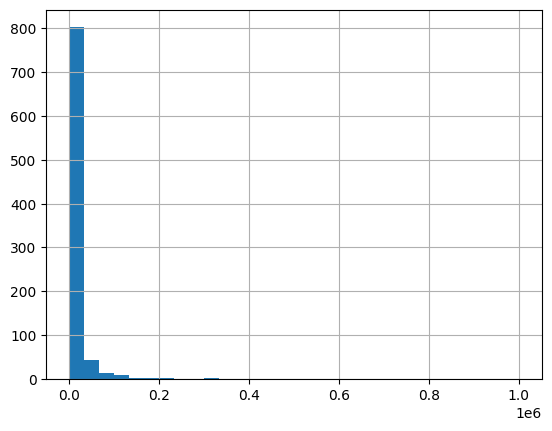

In [21]:
df['SalesValue'].hist(bins=30)

*  Outlier Detection (IQR Method)

In [22]:
Q1 = df['SalesValue'].quantile(0.25)
Q3 = df['SalesValue'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df['SalesValue'] < Q1 - 1.5*IQR) |
    (df['SalesValue'] > Q3 + 1.5*IQR)
]

outliers.shape

(116, 17)